In [3]:
import pandas as pd

df1 = pd.read_csv('data/S07-hw-dataset-01.csv')
df2 = pd.read_csv('data/S07-hw-dataset-02.csv')
df3 = pd.read_csv('data/S07-hw-dataset-03.csv')

In [13]:
def print_dataset_info(df, dataset_name):
    print(f"Датасет: {dataset_name}")
    print()
    print("Размер")
    print(df.shape)
    print()
    print("Первые строки")
    print(df.head())
    print()
    print("info()")
    print(df.info())
    print()
    print("describe()")
    print(df.describe())
    print()
    print("Пропуски")
    missing_total = df.isnull().sum().sum()
    if missing_total > 0:
        print(f"Общее количество пропусков: {missing_total}")
    else:
        print("Пропущенных значений нет")
    print()
    print("Типы признаков")
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    print(f"Числовые признаки: {numeric_cols}")
    print(f"Категориальные признаки: {categorical_cols}")

In [15]:
print_dataset_info(df1, 'S07-hw-dataset-01.csv')
print_dataset_info(df2, 'S07-hw-dataset-02.csv')
print_dataset_info(df3, 'S07-hw-dataset-03.csv')

Датасет: S07-hw-dataset-01.csv

Размер
(12000, 9)

Первые строки
   sample_id        f01        f02       f03         f04        f05  \
0          0  -0.536647 -69.812900 -0.002657   71.743147 -11.396498   
1          1  15.230731  52.727216 -1.273634 -104.123302  11.589643   
2          2  18.542693  77.317150 -1.321686 -111.946636  10.254346   
3          3 -12.538905 -41.709458  0.146474   16.322124   1.391137   
4          4  -6.903056  61.833444 -0.022466  -42.631335   3.107154   

         f06        f07       f08  
0 -12.291287  -6.836847 -0.504094  
1  34.316967 -49.468873  0.390356  
2  25.892951  44.595250  0.325893  
3   2.014316 -39.930582  0.139297  
4  -5.471054   7.001149  0.131213  

info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  12000 non-null  int64  
 1   f01        12000 non-null  float64
 2   f02        

In [17]:
sample_id1 = df1['sample_id']
X1 = df1[['f01', 'f02', 'f03', 'f04', 'f05', 'f06', 'f07', 'f08']]

sample_id2 = df2['sample_id']
X2 = df2[['x1', 'x2', 'z_noise']]

sample_id3 = df3['sample_id']
X3 = df3[['x1', 'x2', 'f_corr', 'f_noise']]

In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# датасет 1, все признаки числовые, пропусков нет
preprocessor1 = Pipeline([
    ('scaler', StandardScaler())
])

X1_scaled = preprocessor1.fit_transform(X1)

X1_preprocessor = preprocessor1

In [27]:
# датасет 2, все признаки числовые, пропусков нет
preprocessor2 = Pipeline([
    ('scaler', StandardScaler())
])

X2_scaled = preprocessor2.fit_transform(X2)

X2_preprocessor = preprocessor2

In [29]:
# датасет 3, все признаки числовые, пропусков нет
preprocessor3 = Pipeline([
    ('scaler', StandardScaler())
])

X3_scaled = preprocessor3.fit_transform(X3)

X3_preprocessor = preprocessor3

In [47]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import numpy as np
import matplotlib.pyplot as plt


plt.rcParams['figure.figsize'] = (12, 8)

# параметры k
k_range = range(2, 21)
silhouette_scores = []
db_scores = []
ch_scores = []
inertia_values = []
all_kmeans_models = []

# перебор k
for k in k_range:
    kmeans = KMeans(n_clusters=k, 
                    random_state=17,
                    n_init=10)
    
    kmeans.fit(X1_scaled)
    all_kmeans_models.append(kmeans)
    
    labels = kmeans.predict(X1_scaled)
    
    # все три метрики
    silhouette = silhouette_score(X1_scaled, labels)
    db = davies_bouldin_score(X1_scaled, labels)
    ch = calinski_harabasz_score(X1_scaled, labels)
    
    silhouette_scores.append(silhouette)
    db_scores.append(db)
    ch_scores.append(ch)
    inertia_values.append(kmeans.inertia_)

# лучший k по silhouette
best_k_silhouette = k_range[np.argmax(silhouette_scores)]
best_kmeans_model = all_kmeans_models[np.argmax(silhouette_scores)]
kmeans_labels_01 = best_kmeans_model.predict(X1_scaled)

In [50]:
# параметры для DBSCAN
eps_values = np.arange(0.1, 1.1, 0.1)
min_samples_options = [3, 5, 10, 20]

dbscan_results = []
best_dbscan = None
best_silhouette = -1

for eps in eps_values:
    for min_samples in min_samples_options:
        try:
            dbscan = DBSCAN(eps=eps, 
                            min_samples=min_samples,
                            n_jobs=-1)
            
            labels = dbscan.fit_predict(X1_scaled)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            n_noise = list(labels).count(-1)
            
            if n_clusters >= 2 and n_clusters < len(X1_scaled) - n_noise:
                mask = labels != -1
                if sum(mask) > 0 and len(np.unique(labels[mask])) >= 2:
                    # метрики только на non-noise точках
                    silhouette = silhouette_score(X1_scaled[mask], labels[mask])
                    db = davies_bouldin_score(X1_scaled[mask], labels[mask])
                    ch = calinski_harabasz_score(X1_scaled[mask], labels[mask])
                else:
                    silhouette = -1
                    db = -1
                    ch = -1
            else:
                silhouette = -1
                db = -1
                ch = -1
            
            result = {
                'eps': eps,
                'min_samples': min_samples,
                'n_clusters': n_clusters,
                'n_noise': n_noise,
                'noise_percentage': (n_noise / len(X1_scaled)) * 100,
                'silhouette': silhouette,
                'davies_bouldin': db,
                'calinski_harabasz': ch,
                'labels': labels,
                'model': dbscan
            }
            dbscan_results.append(result)
            
            if silhouette > best_silhouette:
                best_silhouette = silhouette
                best_dbscan = result
                
        except Exception as e:
            print(f"eps={eps:.1f}, min_samples={min_samples:2d}: ОШИБКА - {e}")

if best_dbscan:
    dbscan_labels_01 = best_dbscan['labels']
else:
    dbscan_labels_01 = None

In [51]:
print("KMeans:")
print(f"Лучшее k: {best_k_silhouette}")
print(f"Silhouette: {max(silhouette_scores):.4f}")
print(f"Davies-Bouldin: {db_scores[np.argmax(silhouette_scores)]:.4f}")
print(f"Calinski-Harabasz: {ch_scores[np.argmax(silhouette_scores)]:.4f}")

if best_dbscan and best_silhouette > 0:
    print("DBSCAN:")
    print(f"Лучшие параметры: eps={best_dbscan['eps']:.1f}, min_samples={best_dbscan['min_samples']}")
    print(f"Silhouette: {best_dbscan['silhouette']:.4f}")
    print(f"Davies-Bouldin: {best_dbscan['davies_bouldin']:.4f}")
    print(f"Calinski-Harabasz: {best_dbscan['calinski_harabasz']:.4f}")
    print(f"Кластеров: {best_dbscan['n_clusters']}")
    print(f"Шума: {best_dbscan['noise_percentage']:.1f}%")
else:
    print("DBSCAN: не найдено моделей с silhouette > 0")

KMeans:
Лучшее k: 2
Silhouette: 0.5216
Davies-Bouldin: 0.6853
Calinski-Harabasz: 11786.9546
DBSCAN:
Лучшие параметры: eps=0.5, min_samples=20
Silhouette: 0.4044
Davies-Bouldin: 1.1427
Calinski-Harabasz: 8750.6559
Кластеров: 5
Шума: 12.2%


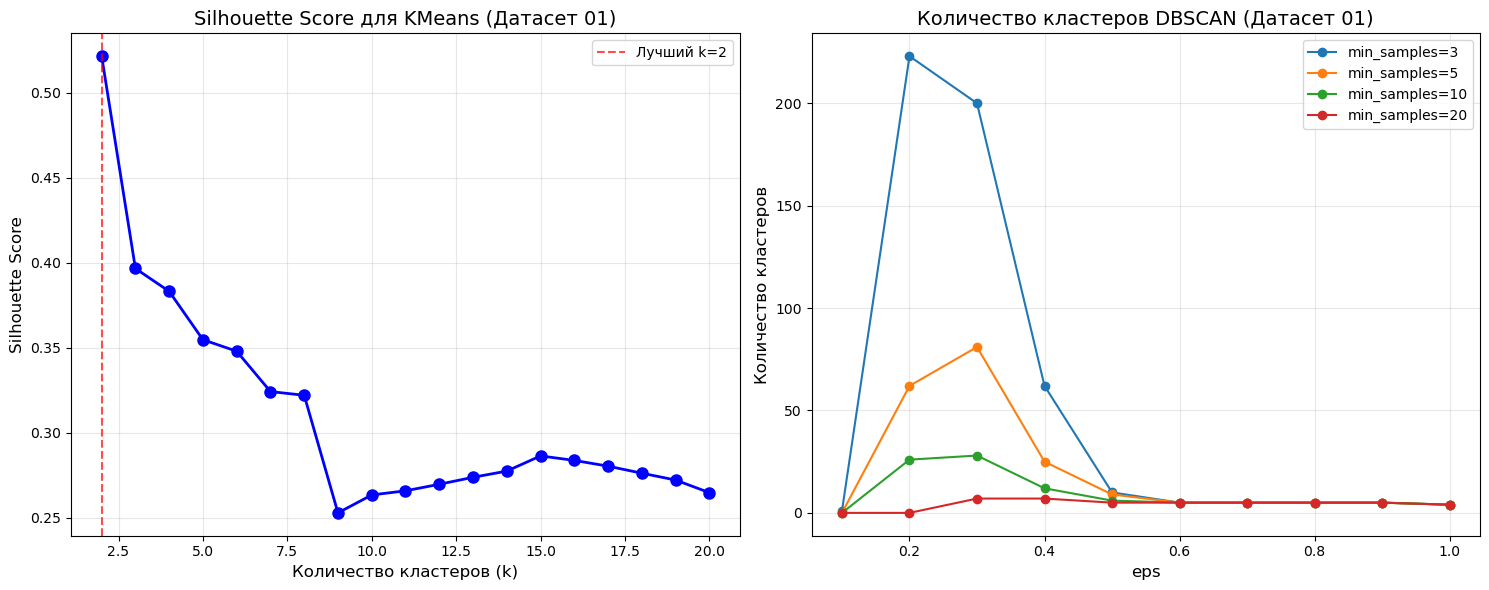

In [102]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Silhouette score vs k для KMeans
axes[0].plot(k_range, silhouette_scores, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Количество кластеров (k)', fontsize=12)
axes[0].set_ylabel('Silhouette Score', fontsize=12)
axes[0].set_title('Silhouette Score для KMeans (Датасет 01)', fontsize=14)
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=best_k_silhouette, color='r', linestyle='--', alpha=0.7, 
                label=f'Лучший k={best_k_silhouette}')
axes[0].legend()

# количество кластеров DBSCAN в зависимости от eps
for min_samples in min_samples_options:
    filtered_results = [r for r in dbscan_results if r['min_samples'] == min_samples]
    if filtered_results:
        eps_vals = [r['eps'] for r in filtered_results]
        n_clusters_vals = [r['n_clusters'] for r in filtered_results]
        axes[1].plot(eps_vals, n_clusters_vals, 'o-', label=f'min_samples={min_samples}')

axes[1].set_xlabel('eps', fontsize=12)
axes[1].set_ylabel('Количество кластеров', fontsize=12)
axes[1].set_title('Количество кластеров DBSCAN (Датасет 01)', fontsize=14)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig(f"artifacts/figures/1_Silhouette_score_vs_k", dpi=300, bbox_inches='tight')
plt.show()

In [53]:
print("1. KMeans показал лучший результат при k =", best_k_silhouette)
print("2. Silhouette score для KMeans:", f"{max(silhouette_scores):.4f}")
if best_dbscan:
    print("3. DBSCAN показал silhouette:", f"{best_dbscan['silhouette']:.4f}")
    print("4. Сравнение:")
    if max(silhouette_scores) > best_dbscan['silhouette']:
        print("KMeans показал лучший silhouette score")
    else:
        print("DBSCAN показал лучший silhouette score")
else:
    print("3. DBSCAN не дал удовлетворительных результатов")

1. KMeans показал лучший результат при k = 2
2. Silhouette score для KMeans: 0.5216
3. DBSCAN показал silhouette: 0.4044
4. Сравнение:
KMeans показал лучший silhouette score


In [104]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 8)

# Датасет 2

k_range = range(2, 21)
silhouette_scores_02 = []
db_scores_02 = []
ch_scores_02 = []
inertia_values_02 = []
all_kmeans_models_02 = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, 
                    random_state=17,
                    n_init=10)
    
    kmeans.fit(X2_scaled)
    all_kmeans_models_02.append(kmeans)
    
    labels = kmeans.predict(X2_scaled)
    
    silhouette = silhouette_score(X2_scaled, labels)
    db = davies_bouldin_score(X2_scaled, labels)
    ch = calinski_harabasz_score(X2_scaled, labels)
    
    silhouette_scores_02.append(silhouette)
    db_scores_02.append(db)
    ch_scores_02.append(ch)
    inertia_values_02.append(kmeans.inertia_)

best_k_silhouette_02 = k_range[np.argmax(silhouette_scores_02)]
best_kmeans_model_02 = all_kmeans_models_02[np.argmax(silhouette_scores_02)]
kmeans_labels_02 = best_kmeans_model_02.predict(X2_scaled)

In [105]:
eps_values_02 = np.arange(0.3, 3.1, 0.2)
min_samples_options_02 = [3, 5, 10, 20]

dbscan_results_02 = []
best_dbscan_02 = None
best_silhouette_02 = -1

for eps in eps_values_02:
    for min_samples in min_samples_options_02:
        try:
            dbscan = DBSCAN(eps=eps, 
                            min_samples=min_samples,
                            n_jobs=-1)
            
            labels = dbscan.fit_predict(X2_scaled)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            n_noise = list(labels).count(-1)
            
            if n_clusters >= 2 and n_clusters < len(X2_scaled) - n_noise:
                mask = labels != -1
                if sum(mask) > 0 and len(np.unique(labels[mask])) >= 2:
                    # метрики только на non-noise точках
                    silhouette = silhouette_score(X2_scaled[mask], labels[mask])
                    db = davies_bouldin_score(X2_scaled[mask], labels[mask])
                    ch = calinski_harabasz_score(X2_scaled[mask], labels[mask])
                else:
                    silhouette = -1
                    db = -1
                    ch = -1
            else:
                silhouette = -1
                db = -1
                ch = -1
            
            result = {
                'eps': eps,
                'min_samples': min_samples,
                'n_clusters': n_clusters,
                'n_noise': n_noise,
                'noise_percentage': (n_noise / len(X2_scaled)) * 100,
                'silhouette': silhouette,
                'davies_bouldin': db,
                'calinski_harabasz': ch,
                'labels': labels,
                'model': dbscan
            }
            dbscan_results_02.append(result)
            
            if silhouette > best_silhouette_02:
                best_silhouette_02 = silhouette
                best_dbscan_02 = result
                
        except Exception as e:
            print(f"eps={eps:.1f}, min_samples={min_samples:2d}: ОШИБКА - {e}")

if best_dbscan_02:
    dbscan_labels_02 = best_dbscan_02['labels']
else:
    dbscan_labels_02 = None

In [106]:
print("KMeans:")
print(f"Лучшее k: {best_k_silhouette_02}")
print(f"Silhouette: {max(silhouette_scores_02):.4f}")
print(f"Davies-Bouldin: {db_scores_02[np.argmax(silhouette_scores_02)]:.4f}")
print(f"Calinski-Harabasz: {ch_scores_02[np.argmax(silhouette_scores_02)]:.4f}")

if best_dbscan_02 and best_silhouette_02 > 0:
    print("DBSCAN:")
    print(f"Лучшие параметры: eps={best_dbscan_02['eps']:.1f}, min_samples={best_dbscan_02['min_samples']}")
    print(f"Silhouette: {best_dbscan_02['silhouette']:.4f}")
    print(f"Davies-Bouldin: {best_dbscan_02['davies_bouldin']:.4f}")
    print(f"Calinski-Harabasz: {best_dbscan_02['calinski_harabasz']:.4f}")
    print(f"Кластеров: {best_dbscan_02['n_clusters']}")
    print(f"Шума: {best_dbscan_02['noise_percentage']:.1f}%")
else:
    print("DBSCAN: не найдено моделей с silhouette > 0")

KMeans:
Лучшее k: 2
Silhouette: 0.3069
Davies-Bouldin: 1.3235
Calinski-Harabasz: 3573.3933
DBSCAN:
Лучшие параметры: eps=0.9, min_samples=20
Silhouette: 0.5242
Davies-Bouldin: 0.5096
Calinski-Harabasz: 142.2269
Кластеров: 2
Шума: 3.2%


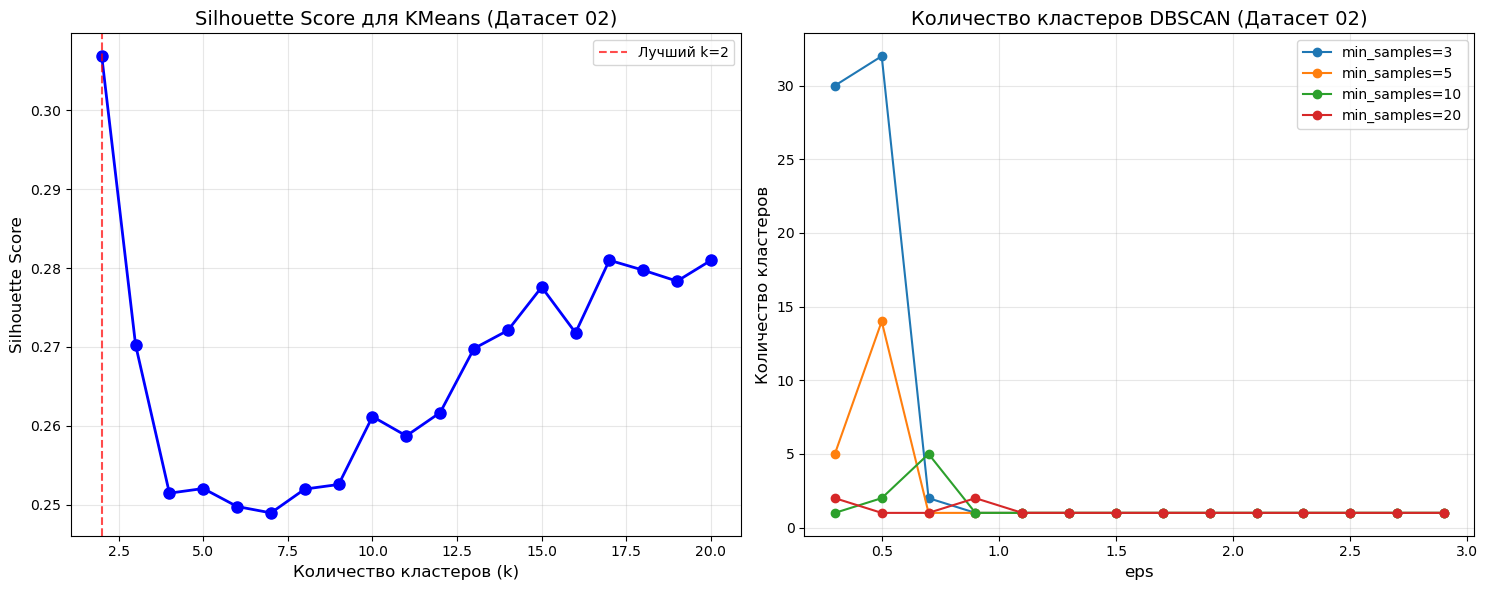

In [112]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].plot(k_range, silhouette_scores_02, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Количество кластеров (k)', fontsize=12)
axes[0].set_ylabel('Silhouette Score', fontsize=12)
axes[0].set_title('Silhouette Score для KMeans (Датасет 02)', fontsize=14)
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=best_k_silhouette_02, color='r', linestyle='--', alpha=0.7, 
                label=f'Лучший k={best_k_silhouette_02}')
axes[0].legend()

for min_samples in min_samples_options_02:
    filtered_results = [r for r in dbscan_results_02 if r['min_samples'] == min_samples]
    if filtered_results:
        eps_vals = [r['eps'] for r in filtered_results]
        n_clusters_vals = [r['n_clusters'] for r in filtered_results]
        axes[1].plot(eps_vals, n_clusters_vals, 'o-', label=f'min_samples={min_samples}')

axes[1].set_xlabel('eps', fontsize=12)
axes[1].set_ylabel('Количество кластеров', fontsize=12)
axes[1].set_title('Количество кластеров DBSCAN (Датасет 02)', fontsize=14)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig(f"artifacts/figures/2_Silhouette_score_vs_k", dpi=300, bbox_inches='tight')
plt.show()

In [114]:
print("1. KMeans показал лучший результат при k =", best_k_silhouette_02)
print("2. Silhouette score для KMeans:", f"{max(silhouette_scores_02):.4f}")
if best_dbscan_02:
    print("3. DBSCAN показал silhouette:", f"{best_dbscan_02['silhouette']:.4f}")
    print("4. Сравнение:")
    if max(silhouette_scores_02) > best_dbscan_02['silhouette']:
        print("KMeans показал лучший silhouette score")
    else:
        print("DBSCAN показал лучший silhouette score")
else:
    print("3. DBSCAN не дал удовлетворительных результатов")

1. KMeans показал лучший результат при k = 2
2. Silhouette score для KMeans: 0.3069
3. DBSCAN показал silhouette: 0.5242
4. Сравнение:
DBSCAN показал лучший silhouette score


In [116]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 8)

# датасет 3

k_range = range(2, 21)
silhouette_scores_03 = []
db_scores_03 = []
ch_scores_03 = []
inertia_values_03 = []
all_kmeans_models_03 = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, 
                    random_state=17,
                    n_init=10)
    
    kmeans.fit(X3_scaled)
    all_kmeans_models_03.append(kmeans)
    
    labels = kmeans.predict(X3_scaled)
    
    silhouette = silhouette_score(X3_scaled, labels)
    db = davies_bouldin_score(X3_scaled, labels)
    ch = calinski_harabasz_score(X3_scaled, labels)
    
    silhouette_scores_03.append(silhouette)
    db_scores_03.append(db)
    ch_scores_03.append(ch)
    inertia_values_03.append(kmeans.inertia_)

best_k_silhouette_03 = k_range[np.argmax(silhouette_scores_03)]
best_kmeans_model_03 = all_kmeans_models_03[np.argmax(silhouette_scores_03)]
kmeans_labels_03 = best_kmeans_model_03.predict(X3_scaled)

In [117]:
eps_values_03 = np.arange(0.3, 3.1, 0.2)
min_samples_options_03 = [3, 5, 10, 20]

dbscan_results_03 = []
best_dbscan_03 = None
best_silhouette_03 = -1

for eps in eps_values_03:
    for min_samples in min_samples_options_03:
        try:
            dbscan = DBSCAN(eps=eps, 
                            min_samples=min_samples,
                            n_jobs=-1)
            
            labels = dbscan.fit_predict(X3_scaled)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            n_noise = list(labels).count(-1)
            
            if n_clusters >= 2 and n_clusters < len(X3_scaled) - n_noise:
                mask = labels != -1
                if sum(mask) > 0 and len(np.unique(labels[mask])) >= 2:
                    # метрики только на non-noise точках
                    silhouette = silhouette_score(X3_scaled[mask], labels[mask])
                    db = davies_bouldin_score(X3_scaled[mask], labels[mask])
                    ch = calinski_harabasz_score(X3_scaled[mask], labels[mask])
                else:
                    silhouette = -1
                    db = -1
                    ch = -1
            else:
                silhouette = -1
                db = -1
                ch = -1
            
            result = {
                'eps': eps,
                'min_samples': min_samples,
                'n_clusters': n_clusters,
                'n_noise': n_noise,
                'noise_percentage': (n_noise / len(X3_scaled)) * 100,
                'silhouette': silhouette,
                'davies_bouldin': db,
                'calinski_harabasz': ch,
                'labels': labels,
                'model': dbscan
            }
            dbscan_results_03.append(result)
            
            if silhouette > best_silhouette_03:
                best_silhouette_03 = silhouette
                best_dbscan_03 = result
                
        except Exception as e:
            print(f"eps={eps:.1f}, min_samples={min_samples:2d}: ОШИБКА - {e}")

if best_dbscan_03:
    dbscan_labels_03 = best_dbscan_03['labels']
else:
    dbscan_labels_03 = None

In [118]:
print("KMeans:")
print(f"Лучшее k: {best_k_silhouette_03}")
print(f"Silhouette: {max(silhouette_scores_03):.4f}")
print(f"Davies-Bouldin: {db_scores_03[np.argmax(silhouette_scores_03)]:.4f}")
print(f"Calinski-Harabasz: {ch_scores_03[np.argmax(silhouette_scores_03)]:.4f}")

if best_dbscan_03 and best_silhouette_03 > 0:
    print("DBSCAN:")
    print(f"Лучшие параметры: eps={best_dbscan_03['eps']:.1f}, min_samples={best_dbscan_03['min_samples']}")
    print(f"Silhouette: {best_dbscan_03['silhouette']:.4f}")
    print(f"Davies-Bouldin: {best_dbscan_03['davies_bouldin']:.4f}")
    print(f"Calinski-Harabasz: {best_dbscan_03['calinski_harabasz']:.4f}")
    print(f"Кластеров: {best_dbscan_03['n_clusters']}")
    print(f"Шума: {best_dbscan_03['noise_percentage']:.1f}%")
else:
    print("DBSCAN: не найдено моделей с silhouette > 0")

KMeans:
Лучшее k: 3
Silhouette: 0.3155
Davies-Bouldin: 1.1577
Calinski-Harabasz: 6957.1626
DBSCAN:
Лучшие параметры: eps=0.3, min_samples=20
Silhouette: 0.3588
Davies-Bouldin: 1.1325
Calinski-Harabasz: 4278.4284
Кластеров: 6
Шума: 37.7%


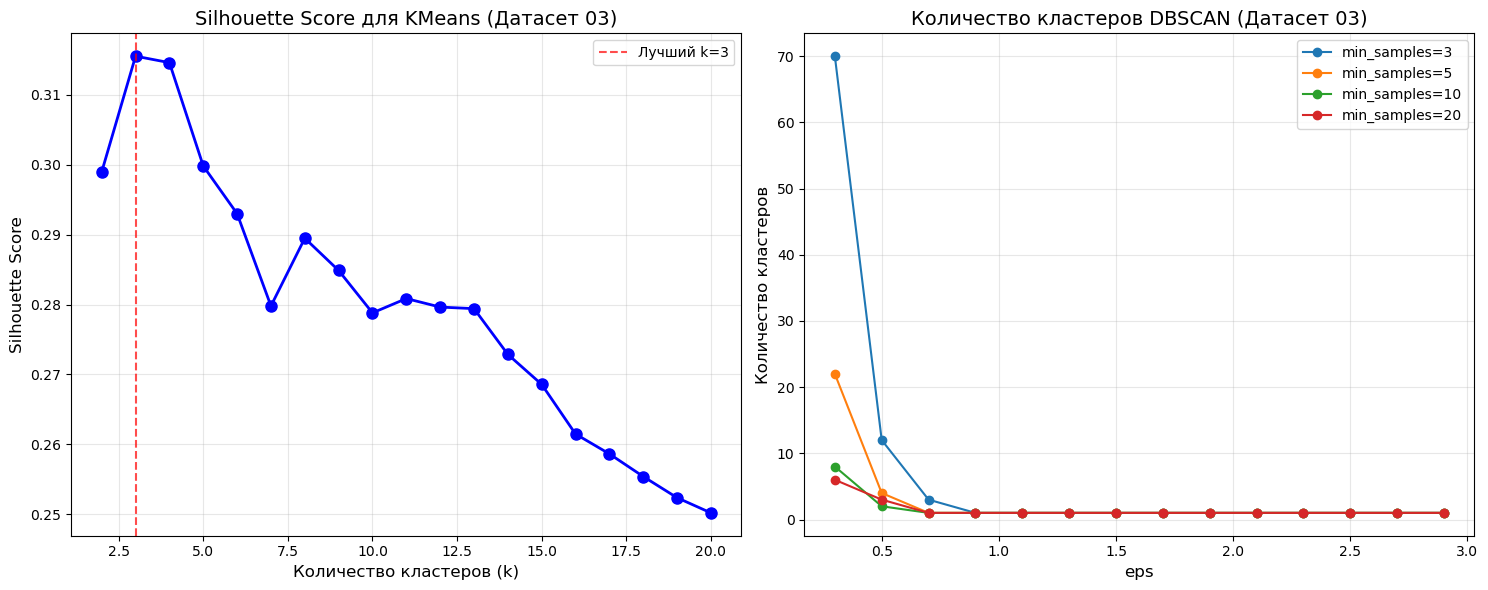

In [122]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].plot(k_range, silhouette_scores_03, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Количество кластеров (k)', fontsize=12)
axes[0].set_ylabel('Silhouette Score', fontsize=12)
axes[0].set_title('Silhouette Score для KMeans (Датасет 03)', fontsize=14)
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=best_k_silhouette_03, color='r', linestyle='--', alpha=0.7, 
                label=f'Лучший k={best_k_silhouette_03}')
axes[0].legend()

for min_samples in min_samples_options_03:
    filtered_results = [r for r in dbscan_results_03 if r['min_samples'] == min_samples]
    if filtered_results:
        eps_vals = [r['eps'] for r in filtered_results]
        n_clusters_vals = [r['n_clusters'] for r in filtered_results]
        axes[1].plot(eps_vals, n_clusters_vals, 'o-', label=f'min_samples={min_samples}')

axes[1].set_xlabel('eps', fontsize=12)
axes[1].set_ylabel('Количество кластеров', fontsize=12)
axes[1].set_title('Количество кластеров DBSCAN (Датасет 03)', fontsize=14)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig(f"artifacts/figures/3_Silhouette_score_vs_k", dpi=300, bbox_inches='tight')
plt.show()

In [126]:
print("1. KMeans показал лучший результат при k =", best_k_silhouette_03)
print("2. Silhouette score для KMeans:", f"{max(silhouette_scores_03):.4f}")
if best_dbscan_03:
    print("3. DBSCAN показал silhouette:", f"{best_dbscan_03['silhouette']:.4f}")
    print("4. Сравнение:")
    if max(silhouette_scores_03) > best_dbscan_03['silhouette']:
        print("KMeans показал лучший silhouette score")
    else:
        print("DBSCAN показал лучший silhouette score")
else:
    print("3. DBSCAN не дал удовлетворительных результатов")

1. KMeans показал лучший результат при k = 3
2. Silhouette score для KMeans: 0.3155
3. DBSCAN показал silhouette: 0.3588
4. Сравнение:
DBSCAN показал лучший silhouette score


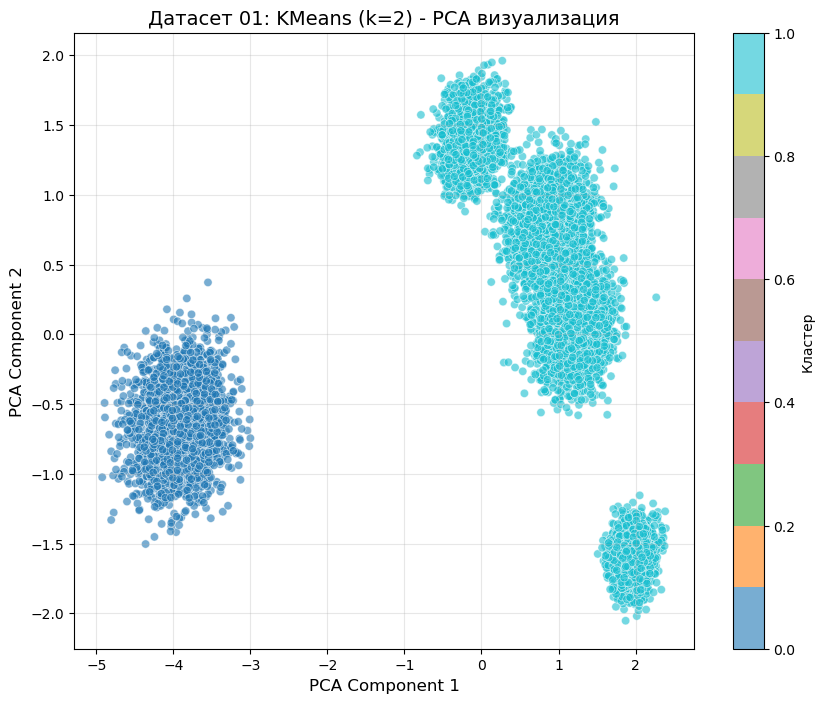

In [128]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import os

os.makedirs('artifacts/figures', exist_ok=True)


pca_01 = PCA(n_components=2)
X1_pca = pca_01.fit_transform(X1_scaled)

plt.figure(figsize=(10, 8))

scatter = plt.scatter(X1_pca[:, 0], X1_pca[:, 1], 
                     c=kmeans_labels_01, 
                     cmap='tab10', 
                     alpha=0.6, 
                     edgecolors='w', 
                     linewidth=0.5)

plt.xlabel('PCA Component 1', fontsize=12)
plt.ylabel('PCA Component 2', fontsize=12)
plt.title('Датасет 01: KMeans (k=2) - PCA визуализация', fontsize=14)
plt.colorbar(scatter, label='Кластер')
plt.grid(True, alpha=0.3)

plt.savefig('artifacts/figures/dataset01_kmeans_pca.png', dpi=300, bbox_inches='tight')
plt.show()

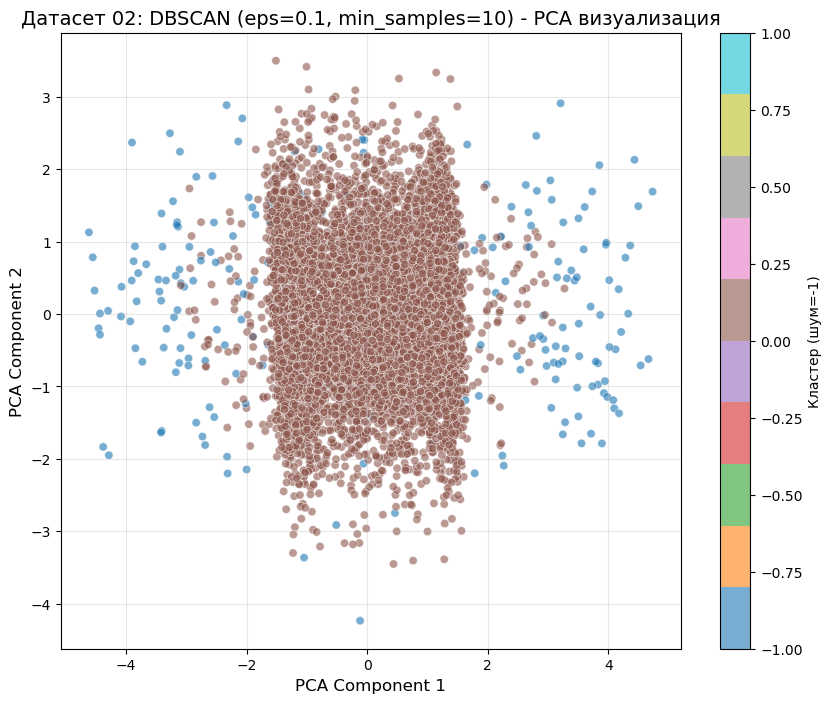

In [129]:
pca_02 = PCA(n_components=2)
X2_pca = pca_02.fit_transform(X2_scaled)

plt.figure(figsize=(10, 8))

scatter = plt.scatter(X2_pca[:, 0], X2_pca[:, 1], 
                     c=dbscan_labels_02, 
                     cmap='tab10', 
                     alpha=0.6, 
                     edgecolors='w', 
                     linewidth=0.5)

plt.xlabel('PCA Component 1', fontsize=12)
plt.ylabel('PCA Component 2', fontsize=12)
plt.title('Датасет 02: DBSCAN (eps=0.1, min_samples=10) - PCA визуализация', fontsize=14)
plt.colorbar(scatter, label='Кластер (шум=-1)')
plt.grid(True, alpha=0.3)

plt.savefig('artifacts/figures/dataset02_dbscan_pca.png', dpi=300, bbox_inches='tight')
plt.show()

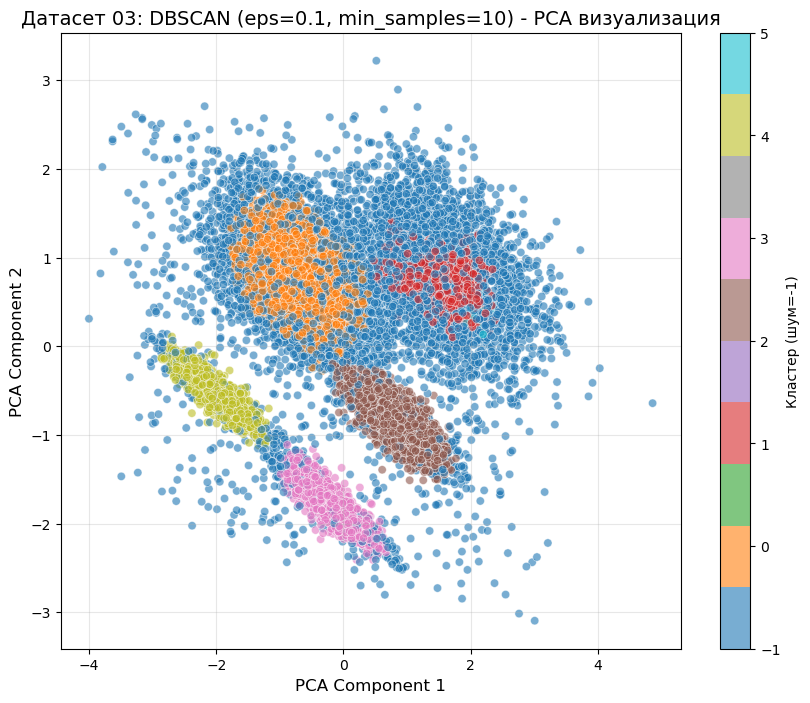

In [130]:
pca_03 = PCA(n_components=2)
X3_pca = pca_03.fit_transform(X3_scaled)

plt.figure(figsize=(10, 8))

scatter = plt.scatter(X3_pca[:, 0], X3_pca[:, 1], 
                     c=dbscan_labels_03, 
                     cmap='tab10', 
                     alpha=0.6, 
                     edgecolors='w', 
                     linewidth=0.5)

plt.xlabel('PCA Component 1', fontsize=12)
plt.ylabel('PCA Component 2', fontsize=12)
plt.title('Датасет 03: DBSCAN (eps=0.1, min_samples=10) - PCA визуализация', fontsize=14)
plt.colorbar(scatter, label='Кластер (шум=-1)')
plt.grid(True, alpha=0.3)

plt.savefig('artifacts/figures/dataset03_dbscan_pca.png', dpi=300, bbox_inches='tight')
plt.show()

In [137]:
from sklearn.metrics import adjusted_rand_score
import numpy as np


# проверка устойчивости для датасета 2

k = 2 
n_runs = 5
random_states = [17, 42, 123, 777, 999] 

all_labels = []
ari_scores = []

# random_state=17, как в основном анализе
kmeans_base = KMeans(n_clusters=k, random_state=17, n_init=10)
labels_base = kmeans_base.fit_predict(X2_scaled)
all_labels.append(labels_base)

print(f"Запуск 1: random_state=17")
print(f"Inertia: {kmeans_base.inertia_:.2f}")

# с разными random_state
for i, rs in enumerate(random_states[1:], 2):
    kmeans = KMeans(n_clusters=k, random_state=rs, n_init=10)
    labels = kmeans.fit_predict(X2_scaled)
    all_labels.append(labels)
    
    ari = adjusted_rand_score(labels_base, labels)
    ari_scores.append(ari)
    
    print(f"Запуск {i}: random_state={rs}")
    print(f"Inertia: {kmeans.inertia_:.2f}")
    print(f"ARI с базовым запуском: {ari:.4f}")


pairwise_ari = []
for i in range(n_runs):
    for j in range(i+1, n_runs):
        ari = adjusted_rand_score(all_labels[i], all_labels[j])
        pairwise_ari.append(ari)
        print(f"Запуск {i+1} vs Запуск {j+1}: ARI = {ari:.4f}")

Запуск 1: random_state=17
Inertia: 16588.50
Запуск 2: random_state=42
Inertia: 16588.50
ARI с базовым запуском: 1.0000
Запуск 3: random_state=123
Inertia: 16588.51
ARI с базовым запуском: 0.9980
Запуск 4: random_state=777
Inertia: 16588.50
ARI с базовым запуском: 1.0000
Запуск 5: random_state=999
Inertia: 16588.50
ARI с базовым запуском: 0.9995
Запуск 1 vs Запуск 2: ARI = 1.0000
Запуск 1 vs Запуск 3: ARI = 0.9980
Запуск 1 vs Запуск 4: ARI = 1.0000
Запуск 1 vs Запуск 5: ARI = 0.9995
Запуск 2 vs Запуск 3: ARI = 0.9980
Запуск 2 vs Запуск 4: ARI = 1.0000
Запуск 2 vs Запуск 5: ARI = 0.9995
Запуск 3 vs Запуск 4: ARI = 0.9980
Запуск 3 vs Запуск 5: ARI = 0.9985
Запуск 4 vs Запуск 5: ARI = 0.9995


In [139]:
print(f"Средний ARI между всеми парами запусков: {np.mean(pairwise_ari):.4f}")
print(f"Минимальный ARI: {np.min(pairwise_ari):.4f}")
print(f"Максимальный ARI: {np.max(pairwise_ari):.4f}")
print(f"Стандартное отклонение ARI: {np.std(pairwise_ari):.4f}")

Средний ARI между всеми парами запусков: 0.9991
Минимальный ARI: 0.9980
Максимальный ARI: 1.0000
Стандартное отклонение ARI: 0.0008


Вывод:
Высокая устойчивость: 

-Средний Adjusted Rand Index (ARI) = 0.9991 (максимум 1.0)

-Минимальный ARI = 0.9980, максимальный = 1.0000

-Все 5 запусков с разными random_state дают практически идентичные разбиения

-Inertia почти не меняется: 16588.50 ± 0.01


KMeans стабильно находит одну и ту же кластерную структуру

Результаты не зависят от инициализации центроидов

Можно доверять полученным кластерам (2 кластера для k=2)


Итоги по датасетам

Датасет 1

Лучший метод: KMeans с k=2

Результаты:

KMeans: silhouette=0.5216, Davies-Bouldin=0.6853

DBSCAN: silhouette=0.4044, Davies-Bouldin=1.1427

Объяснение выбора:

Проблема шкал: Исходные признаки имели разные масштабы (std от 0.5 до 60), что требовало масштабирования

KMeans показал лучшие метрики: Более высокий silhouette и лучший Davies-Bouldin

Интерпретируемость: 2 четких кластера лучше описывают данные, чем 5 кластеров DBSCAN с 12.2% шума

Вывод: KMeans лучше справился с данными после масштабирования, показав четкую двухкластерную структуру без значительного шума




Датасет 2

Лучший метод: DBSCAN с eps=0.9, min_samples=20

Результаты:

KMeans: silhouette=0.3069, Davies-Bouldin=1.3235

DBSCAN: silhouette=0.5242, Davies-Bouldin=0.5096, шум=3.2%

Объяснение выбора:

По описанию датасета содержит нелинейные зависимости

Выбросы: DBSCAN автоматически выделил их как шум (3.2%)

Шумовой признак: DBSCAN устойчив к нерелевантным признакам

Качество кластеризации: DBSCAN показал значительно лучший silhouette (0.5242 vs 0.3069)

Интерпретация: 2 кластера с небольшим шумом реалистичнее для данных с выбросами

Вывод: DBSCAN подтвердил свое преимущество для данных с нелинейной структурой и выбросами, дав осмысленное разбиение на 2 кластера с минимальным шумом

Датасет 3

Лучший метод: DBSCAN с eps=0.3, min_samples=20

Результаты:

KMeans: silhouette=0.3155, Davies-Bouldin=1.1577

DBSCAN: silhouette=0.3588, Davies-Bouldin=1.1325, шум=37.7%

Объяснение выбора:

По описанию датасета содержит кластеры разной плотности

Фоновый шум: DBSCAN выделил 37.7% точек как шум, что соответствует описанию "фоновый шум"

Реалистичность: Высокий процент шума ожидаем для данных с фоновым шумом

Качество: DBSCAN показал лучший silhouette, несмотря на высокий шум

Сложности: Выбор eps был критичен - при малых значениях шум достигал 99.6%

Вывод: DBSCAN правильно идентифицировал фоновый шум и выделил кластеры разной плотности, что соответствует описанию датасета и является более реалистичным, чем жесткое разбиение KMeans 

In [153]:
import json
import pandas as pd
import os
import numpy as np

os.makedirs('artifacts/labels', exist_ok=True)

metrics_summary = {
    "dataset_01": {
        "kmeans": {
            "best_k": int(best_k_silhouette),
            "silhouette": float(max(silhouette_scores)),
            "davies_bouldin": float(db_scores[np.argmax(silhouette_scores)]),
            "calinski_harabasz": float(ch_scores[np.argmax(silhouette_scores)]),
            "noise_percentage": 0.0
        },
        "dbscan": {
            "best_eps": float(best_dbscan['eps']) if best_dbscan else None,
            "best_min_samples": int(best_dbscan['min_samples']) if best_dbscan else None,
            "silhouette": float(best_dbscan['silhouette']) if best_dbscan else None,
            "davies_bouldin": float(best_dbscan['davies_bouldin']) if best_dbscan else None,
            "calinski_harabasz": float(best_dbscan['calinski_harabasz']) if best_dbscan else None,
            "n_clusters": int(best_dbscan['n_clusters']) if best_dbscan else None,
            "noise_percentage": float(best_dbscan['noise_percentage']) if best_dbscan else None
        }
    },
    "dataset_02": {
        "kmeans": {
            "best_k": int(best_k_silhouette_02),
            "silhouette": float(max(silhouette_scores_02)),
            "davies_bouldin": float(db_scores_02[np.argmax(silhouette_scores_02)]),
            "calinski_harabasz": float(ch_scores_02[np.argmax(silhouette_scores_02)]),
            "noise_percentage": 0.0
        },
        "dbscan": {
            "best_eps": float(best_dbscan_02['eps']) if best_dbscan_02 else None,
            "best_min_samples": int(best_dbscan_02['min_samples']) if best_dbscan_02 else None,
            "silhouette": float(best_dbscan_02['silhouette']) if best_dbscan_02 else None,
            "davies_bouldin": float(best_dbscan_02['davies_bouldin']) if best_dbscan_02 else None,
            "calinski_harabasz": float(best_dbscan_02['calinski_harabasz']) if best_dbscan_02 else None,
            "n_clusters": int(best_dbscan_02['n_clusters']) if best_dbscan_02 else None,
            "noise_percentage": float(best_dbscan_02['noise_percentage']) if best_dbscan_02 else None
        }
    },
    "dataset_03": {
        "kmeans": {
            "best_k": int(best_k_silhouette_03),
            "silhouette": float(max(silhouette_scores_03)),
            "davies_bouldin": float(db_scores_03[np.argmax(silhouette_scores_03)]),
            "calinski_harabasz": float(ch_scores_03[np.argmax(silhouette_scores_03)]),
            "noise_percentage": 0.0
        },
        "dbscan": {
            "best_eps": float(best_dbscan_03['eps']) if best_dbscan_03 else None,
            "best_min_samples": int(best_dbscan_03['min_samples']) if best_dbscan_03 else None,
            "silhouette": float(best_dbscan_03['silhouette']) if best_dbscan_03 else None,
            "davies_bouldin": float(best_dbscan_03['davies_bouldin']) if best_dbscan_03 else None,
            "calinski_harabasz": float(best_dbscan_03['calinski_harabasz']) if best_dbscan_03 else None,
            "n_clusters": int(best_dbscan_03['n_clusters']) if best_dbscan_03 else None,
            "noise_percentage": float(best_dbscan_03['noise_percentage']) if best_dbscan_03 else None
        }
    }
}

with open('artifacts/metrics_summary.json', 'w', encoding='utf-8') as f:
    json.dump(metrics_summary, f, indent=2, ensure_ascii=False)

In [155]:
best_configs = {
    "dataset_01": {
        "best_algorithm": "kmeans",
        "parameters": {
            "n_clusters": int(best_k_silhouette),
            "random_state": 17,
            "n_init": 10
        },
        "criterion": "silhouette_score",
        "reason": f"Более высокий silhouette ({max(silhouette_scores):.4f} vs {best_dbscan['silhouette'] if best_dbscan else 0:.4f}), лучший Davies-Bouldin, стабильные результаты"
    },
    "dataset_02": {
        "best_algorithm": "dbscan",
        "parameters": {
            "eps": float(best_dbscan_02['eps']) if best_dbscan_02 else None,
            "min_samples": int(best_dbscan_02['min_samples']) if best_dbscan_02 else None
        },
        "criterion": "silhouette_score",
        "reason": f"Значительно лучший silhouette ({best_dbscan_02['silhouette'] if best_dbscan_02 else 0:.4f} vs {max(silhouette_scores_02):.4f}), обработка выбросов как шума ({best_dbscan_02['noise_percentage'] if best_dbscan_02 else 0:.1f}%), соответствует описанию датасета"
    },
    "dataset_03": {
        "best_algorithm": "dbscan",
        "parameters": {
            "eps": float(best_dbscan_03['eps']) if best_dbscan_03 else None,
            "min_samples": int(best_dbscan_03['min_samples']) if best_dbscan_03 else None
        },
        "criterion": "silhouette_score + соответствие описанию данных",
        "reason": f"Лучший silhouette ({best_dbscan_03['silhouette'] if best_dbscan_03 else 0:.4f} vs {max(silhouette_scores_03):.4f}), правильно идентифицирует фоновый шум ({best_dbscan_03['noise_percentage'] if best_dbscan_03 else 0:.1f}%), соответствует описанию датасета"
    }
}

with open('artifacts/best_configs.json', 'w', encoding='utf-8') as f:
    json.dump(best_configs, f, indent=2, ensure_ascii=False)

In [157]:
# Датасет 1: KMeans с лучшим k
labels_df1 = pd.DataFrame({
    'sample_id': sample_id1,
    'cluster_label': kmeans_labels_01
})
labels_df1.to_csv('artifacts/labels/labels_hw07_ds1.csv', index=False)

# Датасет 2: DBSCAN с лучшими параметрами
labels_df2 = pd.DataFrame({
    'sample_id': sample_id2,
    'cluster_label': dbscan_labels_02
})
labels_df2.to_csv('artifacts/labels/labels_hw07_ds2.csv', index=False)

# Датасет 3: DBSCAN с лучшими параметрами
labels_df3 = pd.DataFrame({
    'sample_id': sample_id3,
    'cluster_label': dbscan_labels_03
})
labels_df3.to_csv('artifacts/labels/labels_hw07_ds3.csv', index=False)
